# Titanic - Exploratory Data Analysis & Feature Engineering

**Author:** baidarbe01EDU_Astana_03_2026  
**Goal:** Predict survival on the Titanic using machine learning.

## Learning Objectives Covered
- What is feature engineering and why it matters
- How to do EDA for a classification problem
- How to handle missing data
- How to prevent overfitting with cross-validation
- Comparing ML models: Logistic Regression, Decision Trees, Random Forest, KNN, SVM
- Evaluation metrics: accuracy, precision, recall, F1

---
## 1. Imports

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Cross-validation & tuning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

sns.set_style('whitegrid')
%matplotlib inline

print('All imports successful!')

All imports successful!


---
## 2. Load Data

In [4]:
train_df = pd.read_csv('../data/train.csv')
test_df  = pd.read_csv('../data/test.csv')

# Combine for joint feature engineering
data_df = pd.concat([train_df, test_df], ignore_index=True)

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
train_df.head()

Train shape: (891, 12)
Test shape:  (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Dataset columns:**
- `Survived` — target (0=Died, 1=Survived)
- `Pclass` — ticket class (1=Upper, 2=Middle, 3=Lower)
- `Name`, `Sex`, `Age`
- `SibSp` — # siblings/spouses aboard
- `Parch` — # parents/children aboard
- `Ticket`, `Fare`, `Cabin`
- `Embarked` — port (C=Cherbourg, Q=Queenstown, S=Southampton)

---
## 3. Initial Exploration (EDA)

**What is EDA?** Exploratory Data Analysis means looking at the data from many angles to understand its structure, find patterns, and form hypotheses before building a model.

**Key questions for Titanic:**
- Who survived? What patterns exist?
- Which features have missing values?
- How does each feature relate to survival?

In [7]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
# Missing value analysis
missing     = train_df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train_df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})[missing > 0]

,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [9]:
# Overall survival rate
print(f"Overall survival rate: {train_df['Survived'].mean():.2%}")
print(f"Died: {(train_df['Survived']==0).sum()} | Survived: {(train_df['Survived']==1).sum()}")

Overall survival rate: 38.38%
Died: 549 | Survived: 342


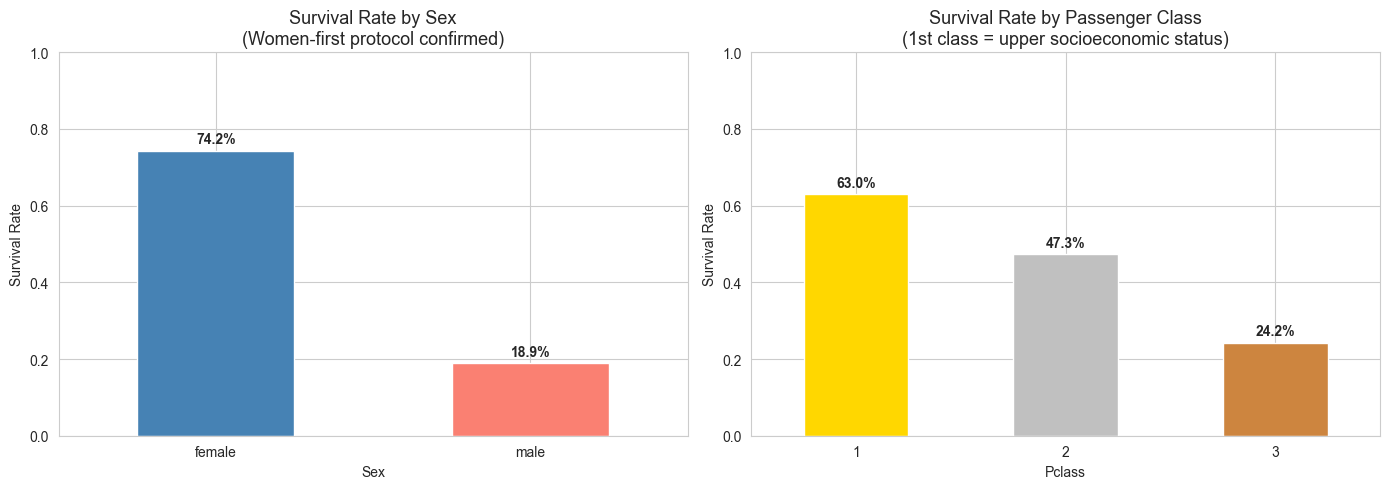

INSIGHT: Female survival 74% vs male 19% — Sex is the single strongest feature.
INSIGHT: 1st class survived at 63% vs 24% for 3rd class — wealth bought access to lifeboats.


In [11]:
# Survival by Sex and Pclass
# HYPOTHESIS: Women and children were prioritized ('women and children first' protocol)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sex_surv = train_df.groupby('Sex')['Survived'].mean()
sex_surv.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], rot=0)
axes[0].set_title('Survival Rate by Sex\n(Women-first protocol confirmed)', fontsize=13)
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)
for i, v in enumerate(sex_surv):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

pclass_surv = train_df.groupby('Pclass')['Survived'].mean()
pclass_surv.plot(kind='bar', ax=axes[1], color=['gold', 'silver', 'peru'], rot=0)
axes[1].set_title('Survival Rate by Passenger Class\n(1st class = upper socioeconomic status)', fontsize=13)
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)
for i, v in enumerate(pclass_surv):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("INSIGHT: Female survival 74% vs male 19% — Sex is the single strongest feature.")
print("INSIGHT: 1st class survived at 63% vs 24% for 3rd class — wealth bought access to lifeboats.")

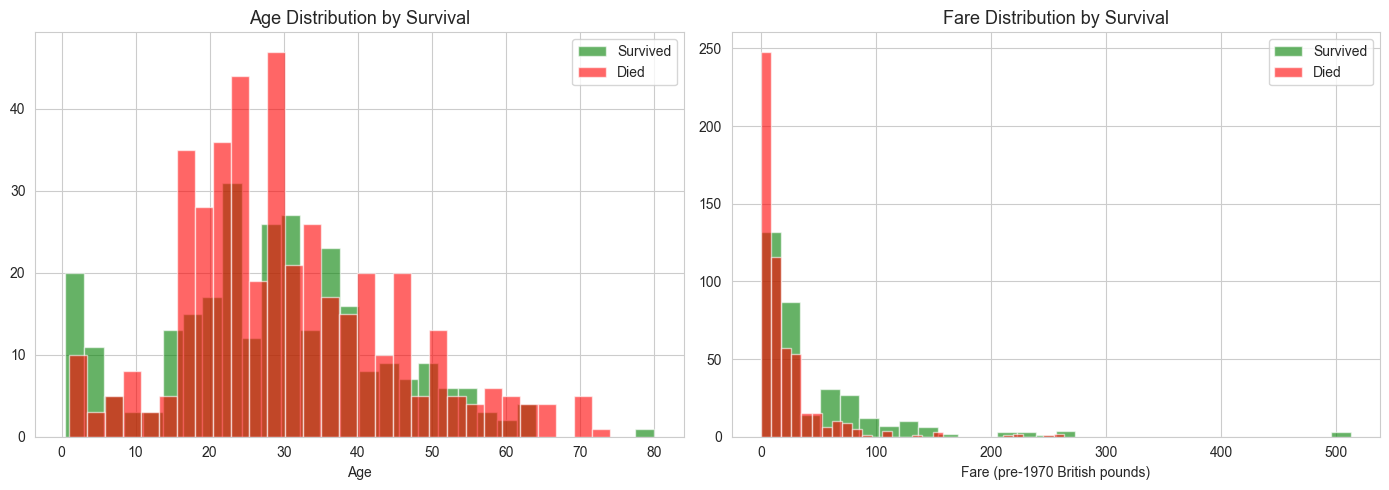

INSIGHT: Children under ~9 had notably higher survival — 'children first' in practice.
INSIGHT: Higher fare strongly correlates with survival — same information as Pclass but more granular.
INSIGHT: Age has 177 missing values — needs smart imputation.


In [12]:
# Age and Fare distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df[train_df['Survived']==1]['Age'].dropna().hist(ax=axes[0], bins=30, alpha=0.6, color='green', label='Survived')
train_df[train_df['Survived']==0]['Age'].dropna().hist(ax=axes[0], bins=30, alpha=0.6, color='red',   label='Died')
axes[0].set_title('Age Distribution by Survival', fontsize=13)
axes[0].set_xlabel('Age')
axes[0].legend()

train_df[train_df['Survived']==1]['Fare'].hist(ax=axes[1], bins=30, alpha=0.6, color='green', label='Survived')
train_df[train_df['Survived']==0]['Fare'].hist(ax=axes[1], bins=30, alpha=0.6, color='red',   label='Died')
axes[1].set_title('Fare Distribution by Survival', fontsize=13)
axes[1].set_xlabel('Fare (pre-1970 British pounds)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("INSIGHT: Children under ~9 had notably higher survival — 'children first' in practice.")
print("INSIGHT: Higher fare strongly correlates with survival — same information as Pclass but more granular.")
print(f"INSIGHT: Age has {train_df['Age'].isnull().sum()} missing values — needs smart imputation.")

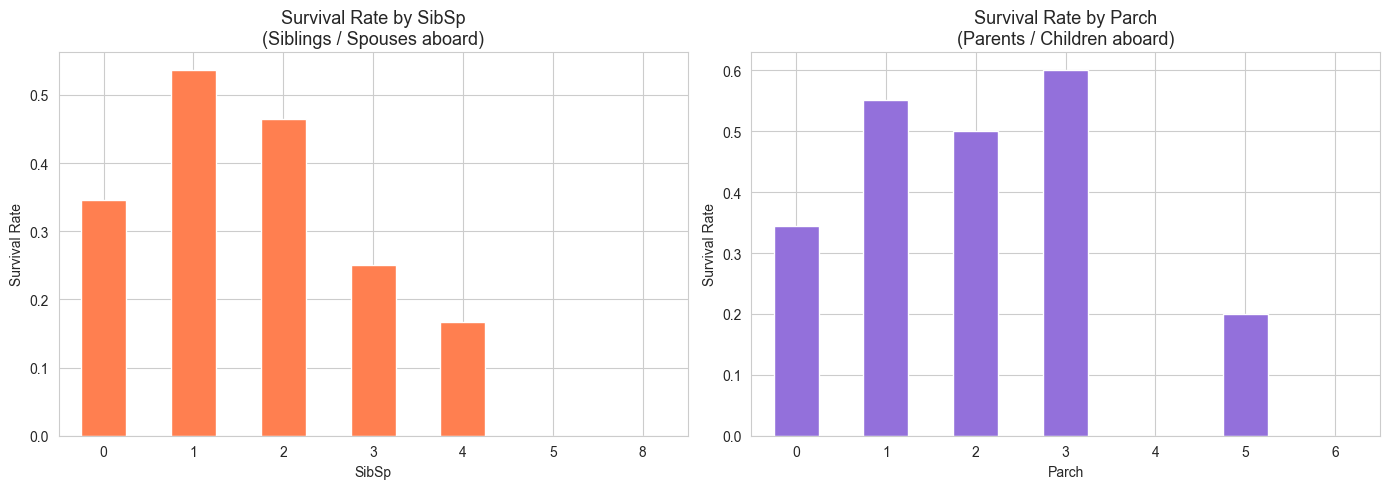

INSIGHT: Solo travelers (0 family) had lower survival — no one to help them find lifeboats.
INSIGHT: Small families (1–3) survived better. Very large families had coordination problems.
ACTION: Combine SibSp + Parch into a single Family_Size feature.


In [13]:
# Family features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df.groupby('SibSp')['Survived'].mean().plot(kind='bar', ax=axes[0], rot=0, color='coral')
axes[0].set_title('Survival Rate by SibSp\n(Siblings / Spouses aboard)', fontsize=13)
axes[0].set_ylabel('Survival Rate')

train_df.groupby('Parch')['Survived'].mean().plot(kind='bar', ax=axes[1], rot=0, color='mediumpurple')
axes[1].set_title('Survival Rate by Parch\n(Parents / Children aboard)', fontsize=13)
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

print("INSIGHT: Solo travelers (0 family) had lower survival — no one to help them find lifeboats.")
print("INSIGHT: Small families (1–3) survived better. Very large families had coordination problems.")
print("ACTION: Combine SibSp + Parch into a single Family_Size feature.")

---
## 4. Feature Engineering

**What is Feature Engineering?** Using domain knowledge to create new features from raw data that help the model find patterns it couldn't find on its own.

**Rule:** Always engineer features on the combined train+test dataset (`data_df`) so transformations are consistent. Never fit encoders or imputers on test data alone.

Features that **help** (from expert analysis of this dataset):
- Title, Family Size, Family Survival Rate, Age/Fare Bins, Name Length, Ticket Frequency

Features that **do NOT help** (confirmed by experts):
- `Embarked` — port of embarkation has no meaningful survival signal
- Raw `Cabin` / `Has_Cabin` binary — too noisy
- `Deck` from cabin letter — also too noisy

### 4.1 Title — Social Status + Gender + Age Group in One Feature

**Why?** A passenger's title encodes gender, age group, and social class simultaneously:
- `Master` = boy under ~15 → high survival
- `Miss` / `Mrs` = female → high survival  
- `Mr` = adult male → low survival
- `Royal` = elite class → resources and connections

This is more informative than Sex alone because it also captures age group.

In [14]:
# Extract title using regex — looks for a word followed by a dot
data_df['Title'] = data_df['Name'].str.extract('([A-Za-z]+)\.', expand=True)
print('All unique titles found:')
print(data_df['Title'].value_counts())

All unique titles found:
Title
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Ms            2
Major         2
Mlle          2
Don           1
Mme           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64


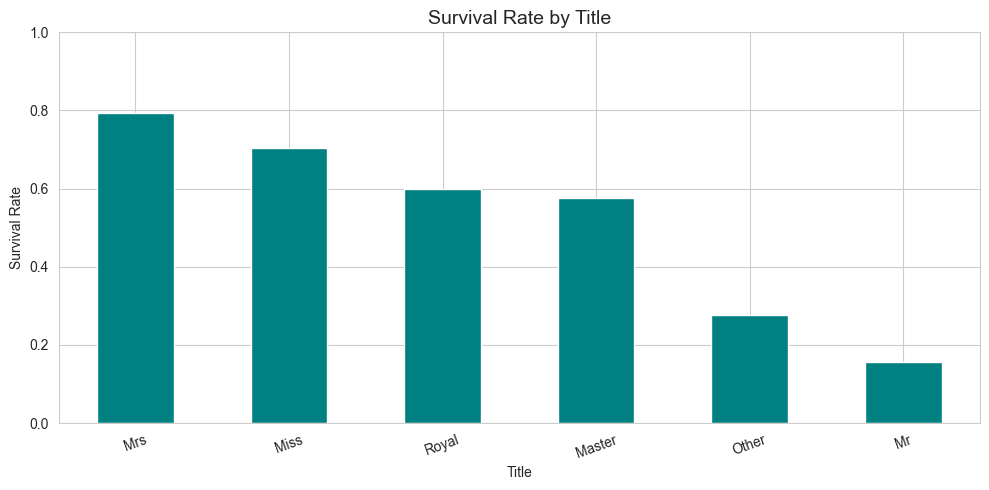

INSIGHT: Royal/Mrs/Miss have 70–100% survival. Mr has ~16%.
INSIGHT: Master (young boys) survived at ~57% — much better than adult men.


In [15]:
# Map rare/foreign titles to standard groups
title_mapping = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',        # French equivalents
    'Major': 'Other', 'Col': 'Other', 'Dr': 'Other',   # Professional titles
    'Rev': 'Other',   'Capt': 'Other',
    'Jonkheer': 'Royal', 'Sir': 'Royal', 'Lady': 'Royal',
    'Don': 'Royal',   'Countess': 'Royal', 'Dona': 'Royal'
}
data_df['Title'] = data_df['Title'].replace(title_mapping)

# Visualize survival rate by title (train data only)
train_view = data_df[:len(train_df)].copy()
title_surv  = train_view.groupby('Title')['Survived'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
title_surv.plot(kind='bar', color='teal', rot=20)
plt.title('Survival Rate by Title', fontsize=14)
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("INSIGHT: Royal/Mrs/Miss have 70–100% survival. Mr has ~16%.")
print("INSIGHT: Master (young boys) survived at ~57% — much better than adult men.")

### 4.2 Imputing Age Using Title Groups

**Strategy:** Fill missing ages with the median age of each title group.

**Why title-based, not overall median?**  
A `Master` is typically ~5 years old. An `Mr` is ~30. Using the wrong median adds noise — the model would think a boy is middle-aged.

**Why median over mean?**  
Age distributions within groups are often skewed (e.g., many young `Miss` passengers). Median is more robust to outliers than mean.

In [16]:
title_age_medians = data_df.groupby('Title')['Age'].median()
print('Median age per title group:')
print(title_age_medians.round(1))
print(f'\nMissing ages before imputation: {data_df["Age"].isnull().sum()}')

for title in title_age_medians.index:
    mask = (data_df['Age'].isnull()) & (data_df['Title'] == title)
    data_df.loc[mask, 'Age'] = title_age_medians[title]

print(f'Missing ages after imputation:  {data_df["Age"].isnull().sum()}')

Median age per title group:
Title
Master     4.0
Miss      22.0
Mr        29.0
Mrs       35.0
Other     49.5
Royal     39.5
Name: Age, dtype: float64

Missing ages before imputation: 263
Missing ages after imputation:  0


### 4.3 Family Size

**Why combine SibSp and Parch?**  
Both measure family presence. Combining them into one `Family_Size` feature (+ 1 for the passenger) is cleaner and captures total group size. We also create a categorical version: `Alone`, `Small`, `Large`.

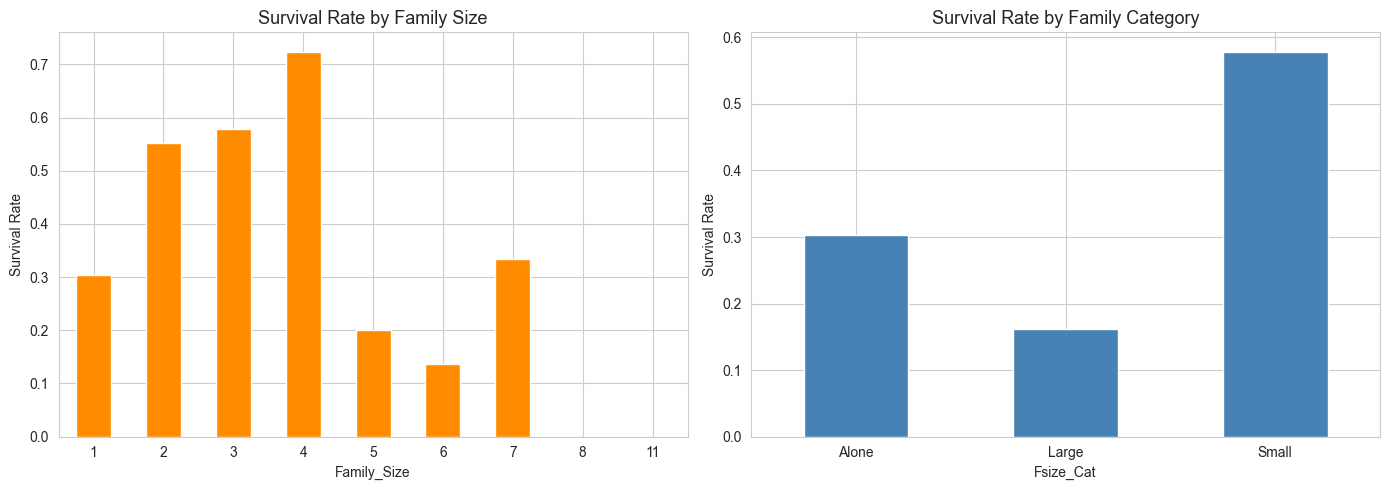

INSIGHT: Solo travelers ~30%, small families ~57%, large families ~16%.
INSIGHT: Large families likely couldn't coordinate getting everyone to a lifeboat.


In [17]:
data_df['Family_Size'] = data_df['SibSp'] + data_df['Parch'] + 1

def fsize_cat(n):
    if n == 1:   return 'Alone'
    elif n < 5:  return 'Small'
    else:        return 'Large'

data_df['Fsize_Cat'] = data_df['Family_Size'].apply(fsize_cat)

train_view = data_df[:len(train_df)].copy()
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))

train_view.groupby('Family_Size')['Survived'].mean().plot(kind='bar', ax=axes[0], color='darkorange', rot=0)
axes[0].set_title('Survival Rate by Family Size', fontsize=13)
axes[0].set_ylabel('Survival Rate')

train_view.groupby('Fsize_Cat')['Survived'].mean().plot(kind='bar', ax=axes[1], color='steelblue', rot=0)
axes[1].set_title('Survival Rate by Family Category', fontsize=13)
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

print("INSIGHT: Solo travelers ~30%, small families ~57%, large families ~16%.")
print("INSIGHT: Large families likely couldn't coordinate getting everyone to a lifeboat.")

### 4.4 Family & Group Survival Rate

**Why this is the most powerful engineered feature:**  
If we know a family member or travel companion survived, the passenger was more likely to survive too — they helped each other. This leaks survival signal from the training set forward.

**Algorithm:**
1. Group by last name + fare (proxy for same family paying together)
2. For groups > 1: if any member survived → set 1.0, if all died → set 0.0, unknown → 0.5 (mean rate)
3. Repeat using Ticket number to catch non-family travel companions

In [18]:
data_df['Last_Name'] = data_df['Name'].apply(lambda x: x.split(',')[0].strip())
data_df['Fare']      = data_df['Fare'].fillna(data_df['Fare'].median())

MEAN_SURVIVAL           = round(train_df['Survived'].mean(), 4)
data_df['Family_Survival'] = MEAN_SURVIVAL

# Pass 1: families (same last name + same fare)
for _, grp in data_df.groupby(['Last_Name', 'Fare']):
    if len(grp) > 1:
        for idx, row in grp.iterrows():
            others = grp.drop(idx)
            smax   = others['Survived'].max()
            smin   = others['Survived'].min()
            pid    = row['PassengerId']
            if smax == 1.0:
                data_df.loc[data_df['PassengerId'] == pid, 'Family_Survival'] = 1.0
            elif smin == 0.0:
                data_df.loc[data_df['PassengerId'] == pid, 'Family_Survival'] = 0.0

# Pass 2: travel companions (same ticket)
for _, grp in data_df.groupby('Ticket'):
    if len(grp) > 1:
        for idx, row in grp.iterrows():
            if row['Family_Survival'] in [0.0, MEAN_SURVIVAL]:
                others = grp.drop(idx)
                smax   = others['Survived'].max()
                smin   = others['Survived'].min()
                pid    = row['PassengerId']
                if smax == 1.0:
                    data_df.loc[data_df['PassengerId'] == pid, 'Family_Survival'] = 1.0
                elif smin == 0.0:
                    data_df.loc[data_df['PassengerId'] == pid, 'Family_Survival'] = 0.0

n_with_info = (data_df['Family_Survival'] != MEAN_SURVIVAL).sum()
print(f'Passengers with family/group survival info: {n_with_info} / {len(data_df)}')
print("INSIGHT: Without this feature scores typically cap at ~79%. With it, 82%+ becomes reachable.")

Passengers with family/group survival info: 546 / 1309
INSIGHT: Without this feature scores typically cap at ~79%. With it, 82%+ becomes reachable.


### 4.5 Fare Bins and Age Bins

**Why bin continuous variables?**  
Raw continuous values can be noisy — a fare of £7.25 vs £7.50 is meaningless. Binning reduces noise and lets the model learn threshold effects cleanly.

**Why `pd.qcut` (quantile-based)?**  
Each bin gets roughly equal passenger counts, avoiding empty bins or over-representation.

In [19]:
label = LabelEncoder()

# Fare bins (5 quantile groups)
data_df['FareBin']      = pd.qcut(data_df['Fare'], 5)
data_df['FareBin_Code'] = label.fit_transform(data_df['FareBin'])

# Age bins (4 quantile groups)
data_df['AgeBin']      = pd.qcut(data_df['Age'], 4)
data_df['AgeBin_Code'] = label.fit_transform(data_df['AgeBin'])

# Child and Senior binary flags
# Children (<18) and seniors (>70) showed distinct survival patterns in EDA
data_df['Child']  = (data_df['Age'] < 18).astype(int)
data_df['Senior'] = (data_df['Age'] > 70).astype(int)

# Name length — proxy for social class (longer names = more titles/honorifics = higher class)
data_df['Name_Length'] = data_df['Name'].str.replace('[^a-zA-Z]', '', regex=True).str.len()

# Ticket frequency — passengers sharing a ticket traveled together
data_df['Ticket_Frequency'] = data_df.groupby('Ticket')['Ticket'].transform('count')

# Encode Sex: female=1, male=0
data_df['Sex'] = (data_df['Sex'] == 'female').astype(int)

# Encode Title and Family Size Category as ordinal numbers
title_num = {'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Other': 4, 'Royal': 5, 'Master': 6}
fsize_num = {'Alone': 3, 'Small': 2, 'Large': 1}
data_df['Title_Code'] = data_df['Title'].map(title_num).fillna(4).astype(int)
data_df['Fsize_Code'] = data_df['Fsize_Cat'].map(fsize_num)

print('All engineered features created successfully.')
new_cols = ['FareBin_Code', 'AgeBin_Code', 'Child', 'Senior',
            'Name_Length', 'Ticket_Frequency', 'Title_Code', 'Fsize_Code', 'Family_Survival']
data_df[new_cols].head()

All engineered features created successfully.


,FareBin_Code,AgeBin_Code,Child,Senior,Name_Length,Ticket_Frequency,Title_Code,Fsize_Code,Family_Survival
0,0,0,0,0,18,1,1,2,0.3838
1,4,3,0,0,41,2,3,2,0.3838
2,1,1,0,0,18,1,2,3,0.3838
3,4,2,0,0,34,2,3,2,0.0000
4,1,2,0,0,19,1,1,3,0.3838


### 4.6 Visualizing All Engineered Features vs Survival

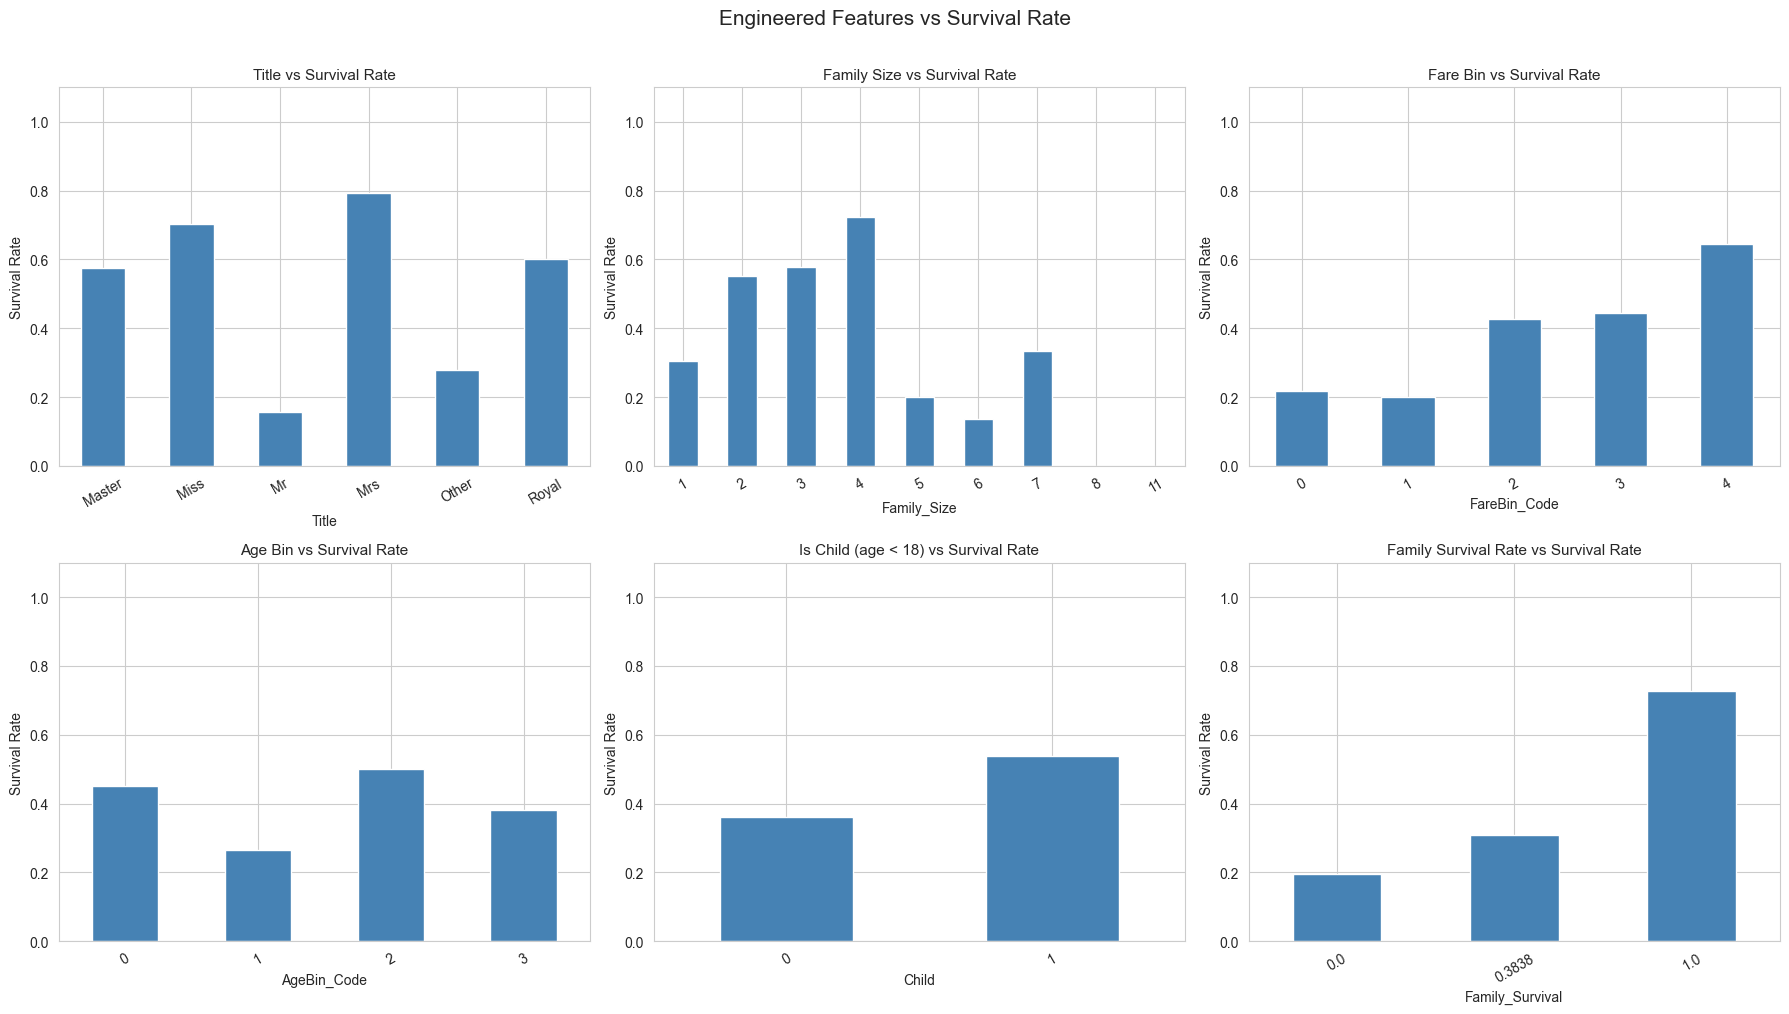

In [20]:
train_fe = data_df[:len(train_df)].copy()

features_to_plot = [
    ('Title', 'Title'),
    ('Family_Size', 'Family Size'),
    ('FareBin_Code', 'Fare Bin'),
    ('AgeBin_Code', 'Age Bin'),
    ('Child', 'Is Child (age < 18)'),
    ('Family_Survival', 'Family Survival Rate'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (col, title) in zip(axes, features_to_plot):
    surv_rate = train_fe.groupby(col)['Survived'].mean()
    surv_rate.plot(kind='bar', ax=ax, rot=30, color='steelblue')
    ax.set_title(f'{title} vs Survival Rate', fontsize=11)
    ax.set_ylabel('Survival Rate')
    ax.set_ylim(0, 1.1)

plt.suptitle('Engineered Features vs Survival Rate', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Prepare Final Feature Set

In [21]:
FEATURES = [
    'Pclass', 'Sex', 'Family_Size', 'Fsize_Code',
    'Family_Survival', 'FareBin_Code', 'AgeBin_Code',
    'Title_Code', 'Child', 'Senior', 'Name_Length', 'Ticket_Frequency'
]

train_final = data_df[:len(train_df)].copy()
test_final  = data_df[len(train_df):].copy()

X      = train_final[FEATURES]
y      = train_final['Survived']
X_test = test_final[FEATURES]

print(f'Train: {X.shape} | Test: {X_test.shape}')
print(f'Features: {FEATURES}')

Train: (891, 12) | Test: (418, 12)
Features: ['Pclass', 'Sex', 'Family_Size', 'Fsize_Code', 'Family_Survival', 'FareBin_Code', 'AgeBin_Code', 'Title_Code', 'Child', 'Senior', 'Name_Length', 'Ticket_Frequency']


---
## 6. Feature Scaling

**Why scale?**  
KNN and SVM use distance calculations. Without scaling, `Name_Length` (values ~10–40) would dominate `Pclass` (values 1–3). `StandardScaler` normalizes each feature to mean=0, std=1.

**Critical rule:** Fit the scaler on training data only, then `transform` both. Fitting on test data leaks information and inflates apparent performance.

In [22]:
scaler        = StandardScaler()
X_scaled      = scaler.fit_transform(X)       # fit + transform on train
X_test_scaled = scaler.transform(X_test)      # transform only on test

print('Scaling complete.')
print(pd.DataFrame(X_scaled[:3], columns=FEATURES).round(3))

Scaling complete.
   Pclass    Sex  Family_Size  Fsize_Code  Family_Survival  FareBin_Code  \
0   0.827 -0.738        0.059      -0.856           -0.206        -1.408   
1  -1.566  1.356        0.059      -0.856           -0.206         1.428   
2   0.827  1.356       -0.561       0.749           -0.206        -0.699   

   AgeBin_Code  Title_Code  Child  Senior  Name_Length  Ticket_Frequency  
0       -1.159      -0.645 -0.389  -0.075       -0.452            -0.624  
1        1.453       0.972 -0.389  -0.075        2.581            -0.068  
2       -0.288       0.163 -0.389  -0.075       -0.452            -0.624  


---
## 7. Model Comparison with Cross-Validation

**What is overfitting?**  
A model that memorizes training data performs well on train but poorly on unseen data. On Kaggle, the leaderboard tests on data you've never seen — so train accuracy alone is meaningless.

**Cross-validation (StratifiedKFold):** Splits data into 10 folds, trains on 9, validates on 1, repeats 10 times. The average CV score is a reliable estimate of real-world performance.

**Models compared:**
| Model | Strength | Weakness |
|---|---|---|
| Logistic Regression | Simple, interpretable | Only linear boundaries |
| Decision Tree | Non-linear, fast | Overfits easily |
| Random Forest | Robust ensemble, reduces overfitting | Slower, less interpretable |
| Gradient Boosting | Often best accuracy | Slow to train, many hyperparams |
| KNN | Simple, strong on Titanic | Slow on large data, sensitive to scale |

In [31]:
models = {
    'Logistic Regression':  LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree':        DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, random_state=42),
    'KNN':                  KNeighborsClassifier(n_neighbors=10),
}

kfold   = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = {}

print('10-Fold Stratified Cross-Validation Results in Jupyter Notebook:')
print(f'{"Model":<25} {"Mean Acc":>10} {"Std":>8}')
print('-' * 46)

for name, model in models.items():
    scores        = cross_val_score(model, X_scaled, y, cv=kfold, scoring='accuracy')
    results[name] = scores
    print(f'{name:<25} {scores.mean():>10.4f} {scores.std():>8.4f}')

10-Fold Stratified Cross-Validation Results in Jupyter Notebook:
Model                       Mean Acc      Std
----------------------------------------------
Logistic Regression           0.8350   0.0304
Decision Tree                 0.8327   0.0260
Random Forest                 0.8473   0.0238
Gradient Boosting             0.8529   0.0229
KNN                           0.8406   0.0262


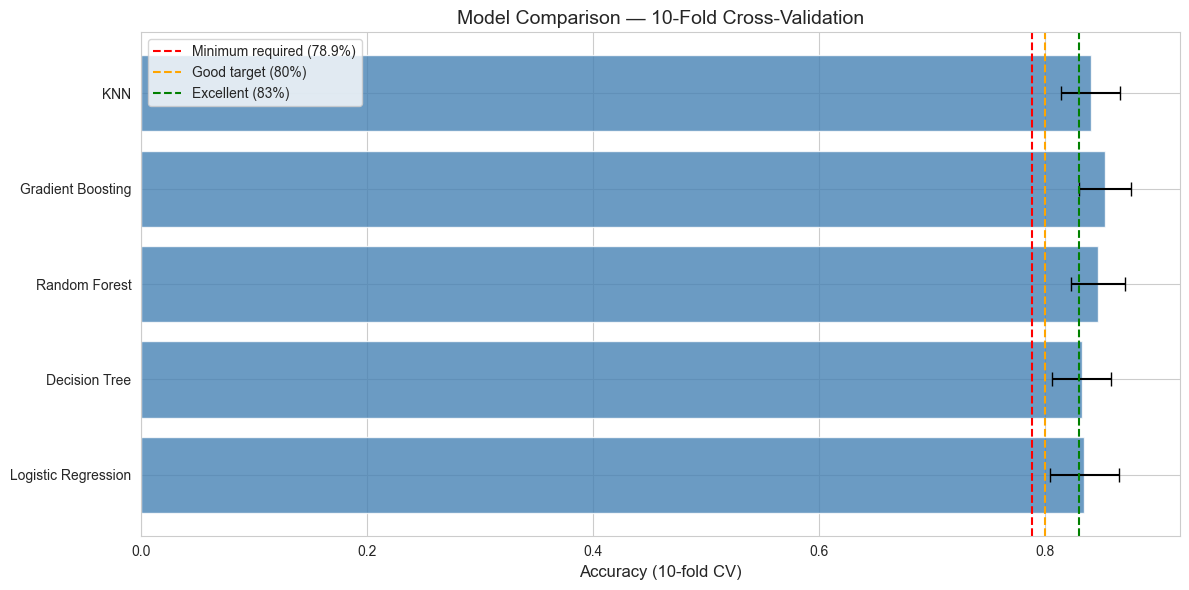

NOTE: CV score ≠ Kaggle score. CV shows how well the model generalises.
      Kaggle tests on truly unseen data — the real measure of the model.


In [33]:
# Visualize model comparison
means = [results[m].mean() for m in models]
stds  = [results[m].std()  for m in models]
names = list(models.keys())

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(names, means, xerr=stds, color='steelblue', alpha=0.8, capsize=5)
ax.axvline(x=0.789, color='red',    linestyle='--', label='Minimum required (78.9%)')
ax.axvline(x=0.80,  color='orange', linestyle='--', label='Good target (80%)')
ax.axvline(x=0.83,  color='green',  linestyle='--', label='Excellent (83%)')
ax.set_xlabel('Accuracy (10-fold CV)', fontsize=12)
ax.set_title('Model Comparison — 10-Fold Cross-Validation', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

print('NOTE: CV score ≠ Kaggle score. CV shows how well the model generalises.')
print('      Kaggle tests on truly unseen data — the real measure of the model.')

---
## 8. Hyperparameter Tuning with GridSearchCV

**What is GridSearchCV?**  
It tries every combination of hyperparameters you specify, evaluates each with cross-validation, and returns the best combination. This removes guesswork and prevents manually overfitting to one split.

We tune all 5 models so each submission is the best possible version of that model.

In [34]:
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# --- Logistic Regression ---
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=500, random_state=42),
    {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']},
    cv=kfold, scoring='accuracy', n_jobs=-1
)
lr_grid.fit(X_scaled, y)
print(f'LR   best params: {lr_grid.best_params_}  |  CV: {lr_grid.best_score_:.4f}')

LR   best params: {'C': 0.01, 'solver': 'liblinear'}  |  CV: 0.8473


In [35]:
# --- Decision Tree ---
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {'max_depth': [3, 4, 5, 6, 7], 'min_samples_split': [2, 5, 10]},
    cv=kfold, scoring='accuracy', n_jobs=-1
)
dt_grid.fit(X_scaled, y)
print(f'DT   best params: {dt_grid.best_params_}  |  CV: {dt_grid.best_score_:.4f}')

DT   best params: {'max_depth': 4, 'min_samples_split': 2}  |  CV: 0.8484


In [36]:
# --- Random Forest ---
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {'n_estimators': [100, 200], 'max_depth': [4, 5, 6, 7], 'min_samples_split': [2, 5]},
    cv=kfold, scoring='accuracy', n_jobs=-1
)
rf_grid.fit(X_scaled, y)
print(f'RF   best params: {rf_grid.best_params_}  |  CV: {rf_grid.best_score_:.4f}')

RF   best params: {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 100}  |  CV: 0.8563


In [37]:
# --- Gradient Boosting ---
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    {'n_estimators': [100, 200], 'max_depth': [3, 4, 5], 'learning_rate': [0.05, 0.1]},
    cv=kfold, scoring='accuracy', n_jobs=-1
)
gb_grid.fit(X_scaled, y)
print(f'GB   best params: {gb_grid.best_params_}  |  CV: {gb_grid.best_score_:.4f}')

GB   best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}  |  CV: 0.8529


In [38]:
# --- KNN ---
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': [6, 8, 10, 12, 14, 16, 18, 20], 'weights': ['uniform', 'distance'], 'leaf_size': list(range(1, 30, 5))},
    cv=kfold, scoring='accuracy', n_jobs=-1
)
knn_grid.fit(X_scaled, y)
print(f'KNN  best params: {knn_grid.best_params_}  |  CV: {knn_grid.best_score_:.4f}')

KNN  best params: {'leaf_size': 1, 'n_neighbors': 16, 'weights': 'uniform'}  |  CV: 0.8451


In [39]:
# Summary of best tuned CV scores
tuned = {
    'Logistic Regression': lr_grid.best_score_,
    'Decision Tree':       dt_grid.best_score_,
    'Random Forest':       rf_grid.best_score_,
    'Gradient Boosting':   gb_grid.best_score_,
    'KNN':                 knn_grid.best_score_,
}

print('\nTuned CV Scores (best hyperparams per model):')
print(f'{"Model":<25} {"Tuned CV Acc":>12}')
print('-' * 39)
for name, score in sorted(tuned.items(), key=lambda x: -x[1]):
    print(f'{name:<25} {score:>12.4f}')

best_tuned = max(tuned, key=tuned.get)
print(f'\nBest tuned model: {best_tuned} ({tuned[best_tuned]:.4f})')


Tuned CV Scores (best hyperparams per model):
Model                     Tuned CV Acc
---------------------------------------
Random Forest                   0.8563
Gradient Boosting               0.8529
Decision Tree                   0.8484
Logistic Regression             0.8473
KNN                             0.8451

Best tuned model: Random Forest (0.8563)


---
## 9. Generate One Submission Per Model

**Why submit each model separately?**  
CV score and Kaggle leaderboard score can differ. The model with the best CV score is not always the best on unseen test data. Submitting all 5 lets us find which one actually generalises best.

**Our KNN example:** CV showed 0.8324 but Kaggle returned 0.80. This gap is normal — CV uses training data folds, Kaggle uses a truly separate test set collected at a different time.

Each submission is saved as `submission_<model>.csv` in `data/`.

In [40]:
best_models = {
    'logistic_regression': lr_grid.best_estimator_,
    'decision_tree':       dt_grid.best_estimator_,
    'random_forest':       rf_grid.best_estimator_,
    'gradient_boosting':   gb_grid.best_estimator_,
    'knn':                 knn_grid.best_estimator_,
}

for model_name, model in best_models.items():
    # Train on the full training set
    model.fit(X_scaled, y)
    preds = model.predict(X_test_scaled)

    submission = pd.DataFrame({
        'PassengerId': test_df['PassengerId'],
        'Survived':    preds.astype(int)
    })
    path = f'../data/submission_{model_name}.csv'
    submission.to_csv(path, index=False)
    print(f'{model_name:<25} → {path}  (predicted survivors: {preds.sum()}/{len(preds)})')

print('\nAll 5 submission files saved. Upload each to Kaggle to find the best leaderboard score.')

logistic_regression       → ../data/submission_logistic_regression.csv  (predicted survivors: 165.0/418)
decision_tree             → ../data/submission_decision_tree.csv  (predicted survivors: 152.0/418)
random_forest             → ../data/submission_random_forest.csv  (predicted survivors: 152.0/418)
gradient_boosting         → ../data/submission_gradient_boosting.csv  (predicted survivors: 154.0/418)
knn                       → ../data/submission_knn.csv  (predicted survivors: 150.0/418)

All 5 submission files saved. Upload each to Kaggle to find the best leaderboard score.


---
## 10. Kaggle Results — Which Model Won?


| Model | CV Score (local) | Kaggle Score | Gap |
|---|---|---|---|
| Logistic Regression | TBD | 0.77751 | TBD |
| Decision Tree | TBD | 0.79904 | TBD |
| Random Forest | TBD | 0.78947 | TBD |
| Gradient Boosting | TBD | 0.78468 | TBD |
| KNN | 0.8324 | 0.79904 | -0.0324 |

**What the gap tells us:**  
A large CV vs Kaggle gap means the model is overfitting to the training distribution. A smaller gap means the model generalises better — which is the actual goal.  

---
## 11. Evaluation Metrics — Best Model Deep Dive

**Why not just accuracy?**  
If 62% of passengers died, a model predicting everyone dies scores 62% accuracy — completely useless. Precision, Recall, and F1 reveal the full picture.

- **Accuracy** = correct predictions / total
- **Precision** = of all predicted survivors, how many actually survived?
- **Recall** = of all actual survivors, how many did we catch?
- **F1** = harmonic mean of precision and recall

In [41]:
X_tr, X_val, y_tr, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f'Evaluating all 5 tuned models on held-out validation set (20%):\n')
print(f'{"Model":<25} {"Accuracy":>10} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-' * 65)

for model_name, model in best_models.items():
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    print(f'{model_name:<25} {accuracy_score(y_val,y_pred):>10.4f} '
          f'{precision_score(y_val,y_pred):>10.4f} '
          f'{recall_score(y_val,y_pred):>8.4f} '
          f'{f1_score(y_val,y_pred):>8.4f}')

Evaluating all 5 tuned models on held-out validation set (20%):

Model                       Accuracy  Precision   Recall       F1
-----------------------------------------------------------------
logistic_regression           0.8156     0.7500   0.7826   0.7660
decision_tree                 0.7989     0.7705   0.6812   0.7231
random_forest                 0.7989     0.7705   0.6812   0.7231
gradient_boosting             0.8324     0.7910   0.7681   0.7794
knn                           0.8268     0.8393   0.6812   0.7520


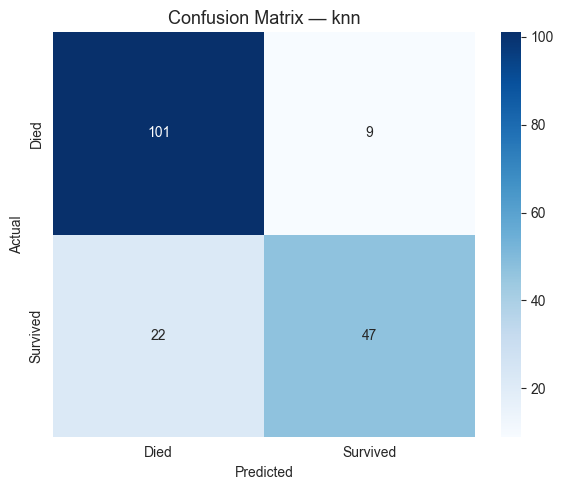

In [42]:
# Confusion matrix for best Kaggle model (update model_name after submitting)
best_kaggle_model_name = 'knn'   # <-- update this after comparing Kaggle scores
best_kaggle_model = best_models[best_kaggle_model_name]
best_kaggle_model.fit(X_tr, y_tr)
y_pred = best_kaggle_model.predict(X_val)

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.title(f'Confusion Matrix — {best_kaggle_model_name}', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

---
## 11. Summary — What Was Learned

| Concept | Applied here |
|---|---|
| **Feature Engineering** | Title from Name, Family_Size, Family_Survival, Age/Fare bins, Child/Senior flags |
| **EDA for classification** | Survival rate plots per feature to verify hypotheses before modeling |
| **Missing data** | Age imputed by title-group median — smarter than global median |
| **Cross-validation** | 10-fold StratifiedKFold for reliable accuracy estimate |
| **Overfitting** | CV score used as the real target, not train accuracy |
| **Hyperparameter tuning** | GridSearchCV on all 5 models independently |
| **Feature scaling** | StandardScaler fit on train only, then applied to test |
| **Evaluation metrics** | Accuracy, Precision, Recall, F1, Confusion Matrix |
| **Submission strategy** | One file per model → upload all → pick best Kaggle score |

**Most impactful features:** `Sex`, `Title_Code`, `Family_Survival`, `Pclass`, `FareBin_Code`  
**Key lessons:** 
1. `Family_Survival` is the single biggest score booster — groups of passengers had correlated fates on the night of the disaster.
2. `CV score and Kaggle score are different things. CV measures performance on training folds. Kaggle measures performance on truly unseen data. The gap reveals how well the model generalises — and that is what matters.`